In [1]:
import sctm

import squidpy as sq
import anndata as adata
import mudata as md
import muon as mu
import scanpy as sc
import matplotlib.pyplot as plt
from omics_topic.models.amortizedLDA import MultimodalAmortizedLDA

import warnings
warnings.filterwarnings('ignore', message='.*was not registered in the param store.*')
warnings.filterwarnings('ignore', message='.*Found plate statements in guide but not model.*')

/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import Dis

In [2]:
adata = sq.datasets.visium_hne_adata()  # H&E-stained Visium section

/tmp/ipykernel_3573273/1818553334.py:5: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata)


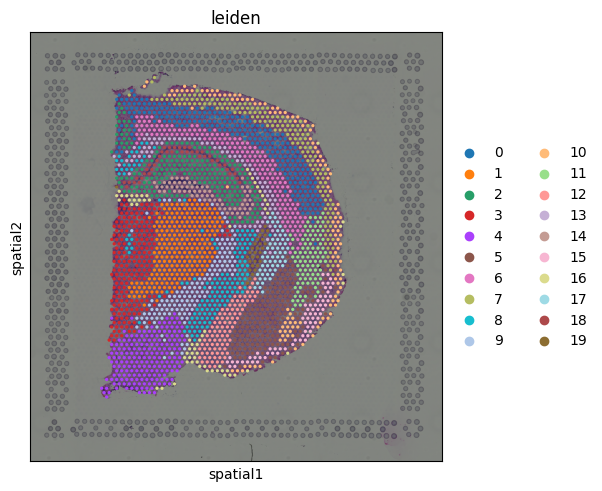

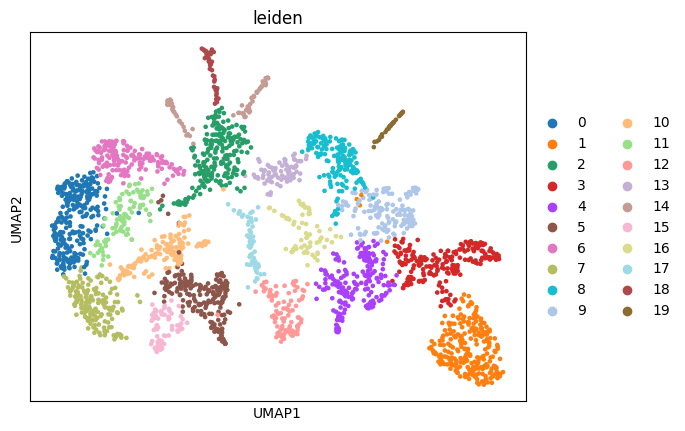

In [3]:
#Let's have a look at the dataset
adata.uns.pop("leiden_colors", None)

# If Leiden was recomputed elsewhere, re-run it to be safe
sc.tl.leiden(adata)
sq.pl.spatial_scatter(adata, color="leiden")
sc.pl.umap(adata, color = 'leiden')

In [4]:
adata

AnnData object with n_obs × n_vars = 2688 × 18078
    obs: 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts', 'leiden', 'cluster'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'cluster_colors', 'hvg', 'leiden', 'neighbors', 'pca', 'rank_genes_groups', 'spatial', 'umap', 'leiden_colors'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [5]:
adata.X = adata.raw.X

In [7]:
model = MultimodalAmortizedLDA.from_data(
    adata,
    n_topics=10,
    likelihoods=["gamma_poisson"],
    cell_topic_prior=1/10,
    kl_weight=1,
    use_feature_background=False,
    #spatial_keys='connectivities',
)
'''for enc in model.module.guide.gcn_encoders:
    enc.alpha_param.requires_grad_(False)
    enc.alpha=0.95'''


'for enc in model.module.guide.gcn_encoders:\n    enc.alpha_param.requires_grad_(False)\n    enc.alpha=0.95'

In [8]:
print("spatial flag:", model.spatial)                             # should be True
print("use_gcn:", model.module.guide.use_gcn)                     # should be True
print("adjacency set:", model.module.guide.adjacency is not None) # True
print("gcn encoders:", model.module.guide.gcn_encoders is not None)

spatial flag: False
use_gcn: False
adjacency set: False
gcn encoders: False


In [9]:
model.train(
    max_epochs=200,
    batch_size=256,  
    train_size=0.8,         
    validation_size=0.2,       
    log_every_n_steps=1,     
    plan_kwargs={"optim_kwargs": {"lr": 1e-2}},
)


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: You are using a CUDA device ('NVIDIA A100-PCIE-40GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
INFO:lightning.pytorch.utilities.rank_zero:You are using a CUDA device ('NVIDIA A100-PCIE-40GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for p

Epoch 200/200: 100%|██████████| 200/200 [01:05<00:00,  3.05it/s, v_num=1, elbo_val=8.77e+6, elbo_train=3.38e+7]

INFO: `Trainer.fit` stopped: `max_epochs=200` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=200` reached.


Epoch 200/200: 100%|██████████| 200/200 [01:05<00:00,  3.05it/s, v_num=1, elbo_val=8.77e+6, elbo_train=3.38e+7]


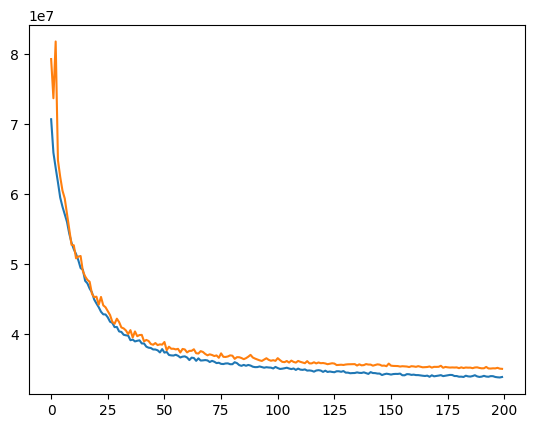

In [10]:
plt.plot(model.history['elbo_train'])
plt.plot(model.history['elbo_val']*4)

... storing 'top_topic' as categorical


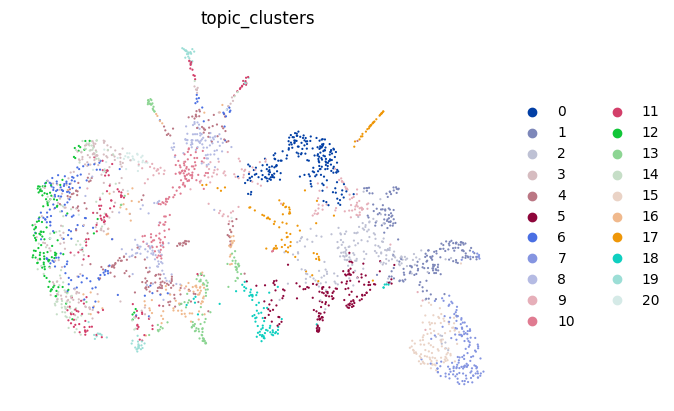

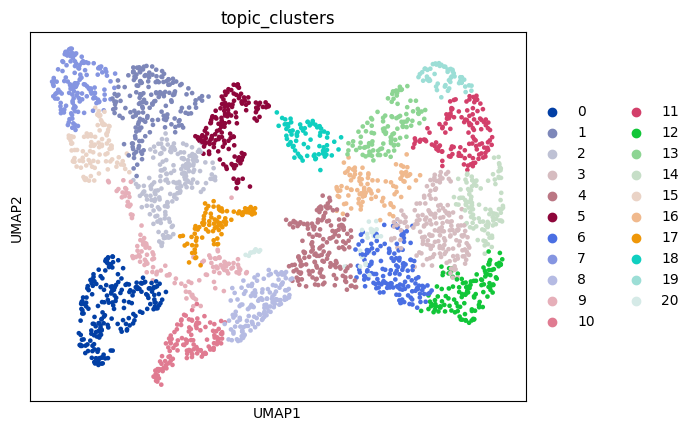

In [11]:
import numpy as np
import pandas as pd
import scanpy as sc

# 1) Topic proportions per cell, visualized on UMAP
theta = model.get_latent_representation(adata, batch_size=adata.n_obs)  # full batch
adata.obsm["X_topic"] = theta.values-1
adata.obs["top_topic"] = theta.idxmax(axis=1)


sc.pp.neighbors(adata, metric='cosine', use_rep='X_topic', key_added='topic_neighbors')
sc.tl.leiden(adata, neighbors_key = 'topic_neighbors', key_added= 'topic_clusters')
sc.pl.umap(adata, color=["topic_clusters"], frameon=False, s=10)
sc.tl.umap(adata, neighbors_key='topic_neighbors')
sc.pl.umap(adata, color='topic_clusters')

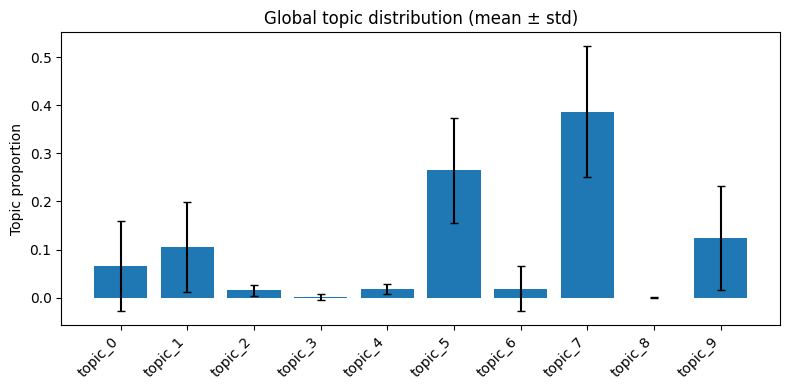

In [12]:
import matplotlib.pyplot as plt
import numpy as np

theta = model.get_latent_representation(adata, batch_size=adata.n_obs)  # full batch for GCN

means = theta.mean(axis=0)
stds = theta.std(axis=0)

plt.figure(figsize=(8, 4))
plt.bar(np.arange(len(means)), means.values, yerr=stds.values, capsize=3)
plt.xticks(np.arange(len(means)), means.index, rotation=45, ha="right")
plt.ylabel("Topic proportion")
plt.title("Global topic distribution (mean ± std)")
plt.tight_layout()
plt.show()


In [13]:
adata

AnnData object with n_obs × n_vars = 2688 × 18078
    obs: 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts', 'leiden', 'cluster', '_indices', 'top_topic', 'topic_clusters'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'cluster_colors', 'hvg', 'leiden', 'neighbors', 'pca', 'rank_genes_groups', 'spatial', 'umap', 'leiden_colors', '_scvi_uuid', '_scvi_manager_uuid', 'topic_neighbors', 'topic_clusters', 'topic_clusters_colors'
    obsm: 'X_pca', 'X_umap', 'spatial', 'X_topic'
    varm: 'PCs'
    ob

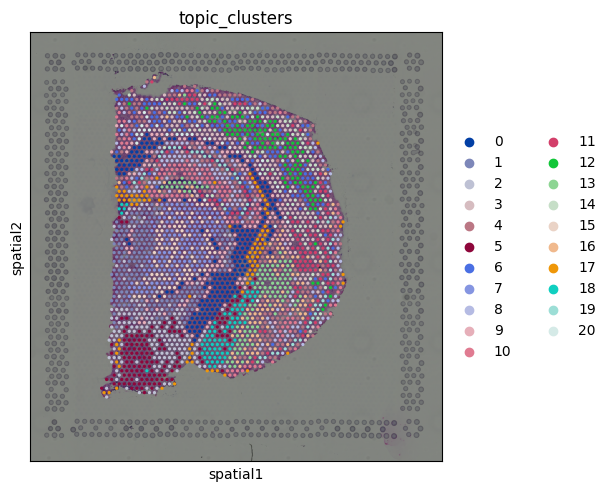

In [14]:
sq.pl.spatial_scatter(adata, color=["topic_clusters"])

In [ ]:
import sctm
import torch
torch.set_float32_matmul_precision("medium")

adata.obsp['spatial_connectivities']=adata.obsp['connectivities']

In [ ]:
model = sctm.stamp.STAMP(adata, 10, gene_likelihood ='nb')

Computing background frequencies


In [ ]:
model.train(learning_rate = 0.01, batch_size = 1296, shuffle = True, min_epochs = 400, max_epochs=400)

Epoch Loss:14007.405: 100%|██████████| 400/400 [03:58<00:00,  1.68it/s]


In [ ]:
topic_prop = model.get_cell_by_topic()
adata.uns.pop("leiden_colors", None)
adata.obsm['X_topic']=topic_prop-1
sc.pp.neighbors(adata, metric='cosine', use_rep='X_topic', key_added='topic_neighbors')
sc.tl.leiden(adata, neighbors_key = 'topic_neighbors', key_added= 'topic_clusters')
# Drop palette so Scanpy rebuilds it
adata.uns.pop("topic_clusters_colors", None)
sc.pl.umap(adata, color=["topic_clusters"], frameon=False, s=10)
sc.tl.umap(adata, neighbors_key='topic_neighbors')
sc.pl.umap(adata, color='topic_clusters')

TypeError: expected Tensor as element 0 in argument 0, but got NoneType

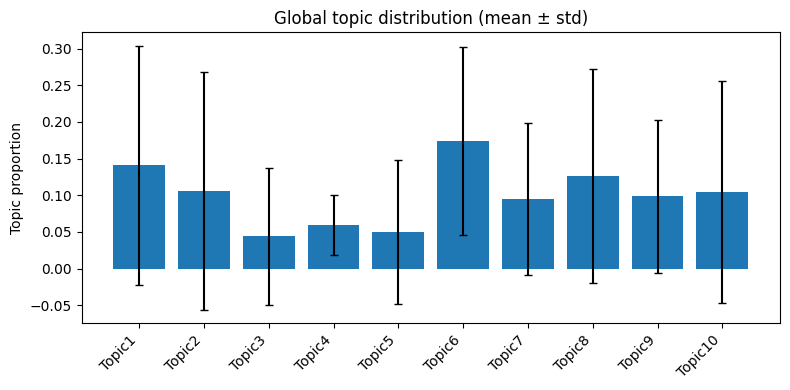

In [ ]:
means = topic_prop.mean(axis=0)
stds = topic_prop.std(axis=0)

plt.figure(figsize=(8, 4))
plt.bar(np.arange(len(means)), means.values, yerr=stds.values, capsize=3)
plt.xticks(np.arange(len(means)), means.index, rotation=45, ha="right")
plt.ylabel("Topic proportion")
plt.title("Global topic distribution (mean ± std)")
plt.tight_layout()
plt.show()

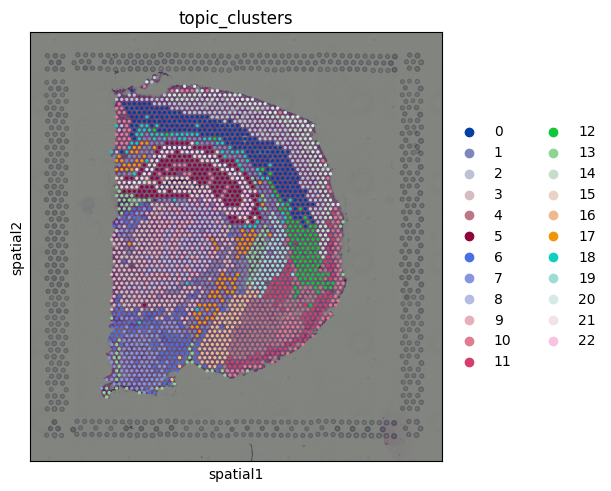

In [ ]:
sq.pl.spatial_scatter(adata, color=["topic_clusters"])